In [27]:
# Loading Data  
import pandas as pd
df=pd.read_csv("train.csv")


In [28]:
# Data Cleaning
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

In [29]:
df.columns=df.columns.str.lower().str.replace(" ","_")  # Changed column names
#df["order_date"]=df["order_date"].dt.strftime("%d-%m-%y")  # Changed date format 
df["order_date"]=pd.to_datetime(df["order_date"],dayfirst=True)
df

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub-category,product_name,sales
0,1,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,9796,CA-2017-125920,2017-05-21,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.7980
9796,9797,CA-2016-128608,2016-01-12,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.3680
9797,9798,CA-2016-128608,2016-01-12,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.1880
9798,9799,CA-2016-128608,2016-01-12,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.3760


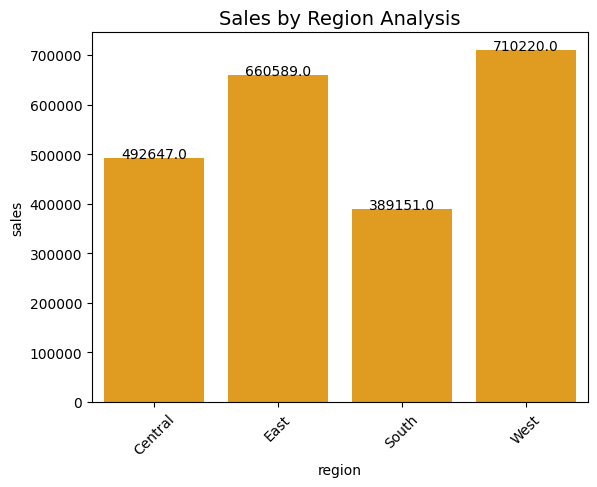

In [30]:
#  which Region generates Maximum Sales
region_sales=df.groupby("region")["sales"].sum().reset_index()

import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot(x="region",y="sales",data=region_sales,color="orange") 
plt.title("Sales by Region Analysis",fontsize=14)
plt.xticks(rotation=45)
for i,value in enumerate(region_sales["sales"]):
    plt.text(i,value,round(value,0),ha="center")
plt.show()    

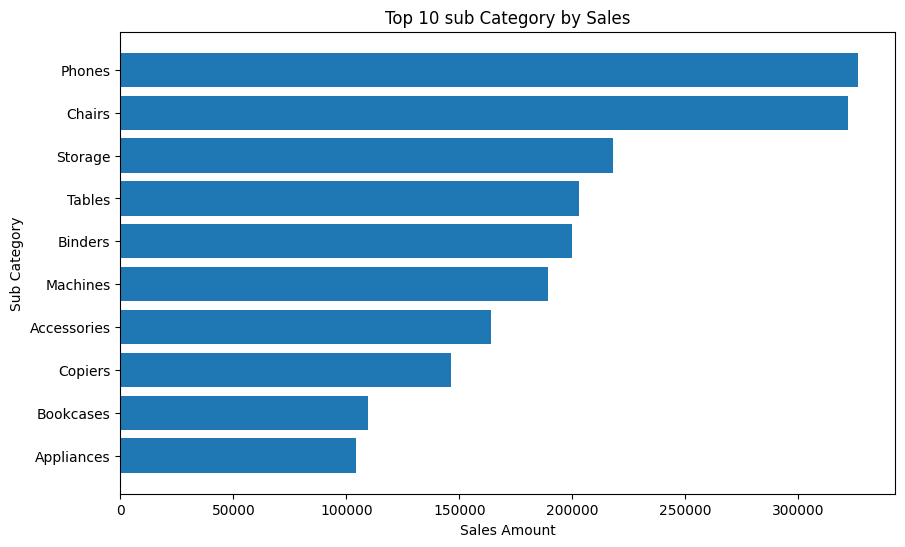

In [31]:
# Which Sub-category Performs the best
cat_sub_sale=df.groupby(["category","sub-category"])["sales"].sum().sort_values(ascending=False).reset_index()
top10=cat_sub_sale.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10["sub-category"],top10["sales"])
plt.xlabel("Sales Amount")
plt.ylabel("Sub Category")
plt.title("Top 10 sub Category by Sales")
plt.gca().invert_yaxis()    # highest on top
plt.show()

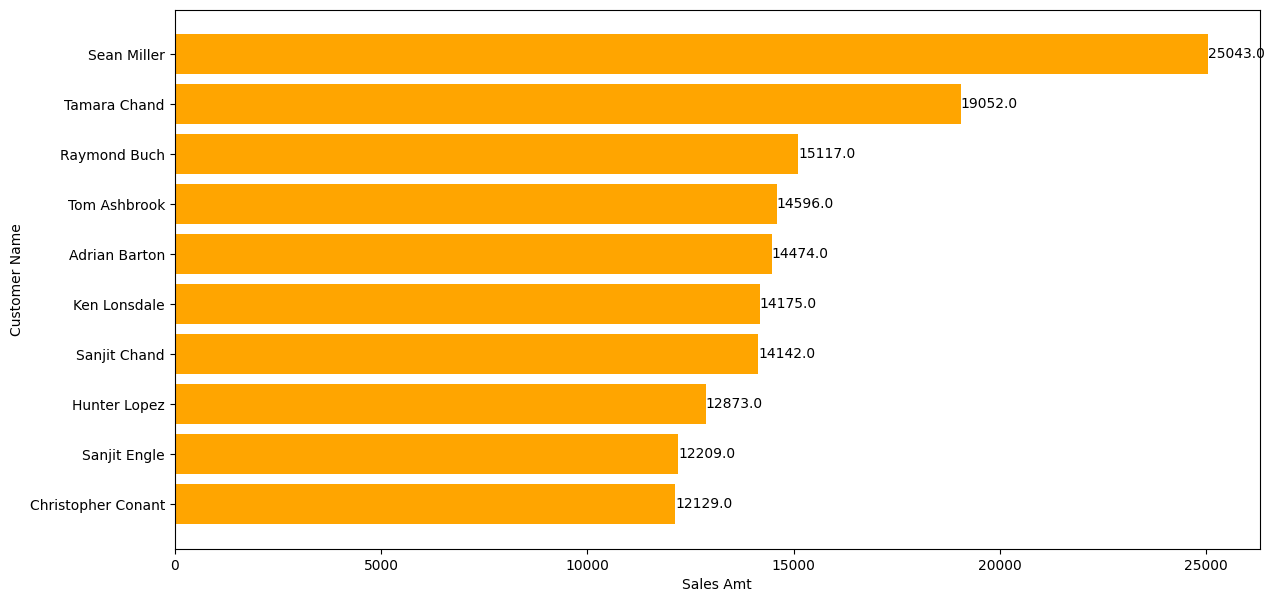

In [32]:
# TOP 10 Customers By Sales
topcustomers=df.groupby("customer_name")["sales"].sum().sort_values(ascending=False).head(10)
topcustomers=topcustomers.reset_index()

plt.figure(figsize=(14,7))
plt.barh(topcustomers["customer_name"],topcustomers["sales"],color="orange")
plt.xlabel("Sales Amt")
plt.ylabel("Customer Name")
plt.gca().invert_yaxis()
for i,v in enumerate(topcustomers["sales"]):
    plt.text(v,i,round(v,0),va="center")
plt.show()

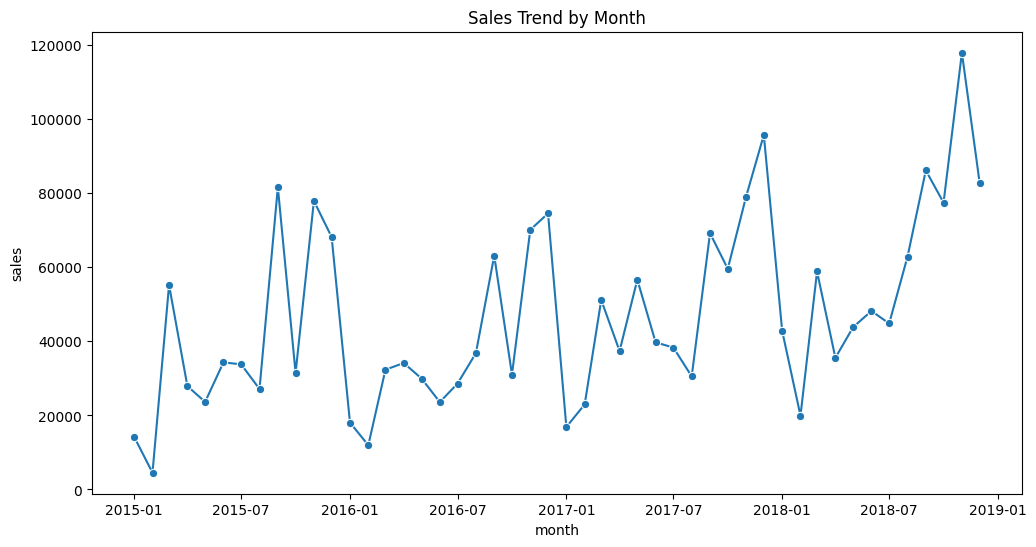

In [33]:
# Monthly SALE TREND
df["month"]=df["order_date"].dt.to_period("M")
monthlysales=df.groupby("month")["sales"].sum()
monthlysales=monthlysales.reset_index()
monthlysales["month"]=monthlysales["month"].dt.to_timestamp()

plt.figure(figsize=(12,6))
sns.lineplot(data=monthlysales,x="month",y="sales",marker="o",)
plt.title("Sales Trend by Month")
plt.show()

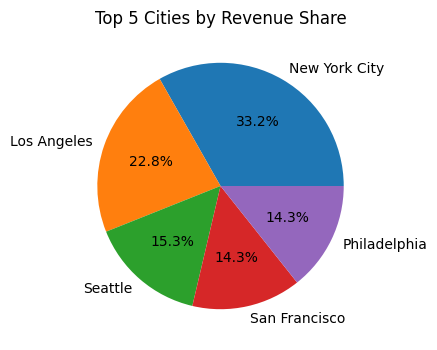

In [34]:
# TOP 5 CITIES DRIVE THE MOST REVENUES
top5cities=df.groupby("city")["sales"].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(4,4))
plt.pie(top5cities,labels=top5cities.index,autopct='%1.1f%%')
plt.title("Top 5 Cities by Revenue Share")
plt.show()

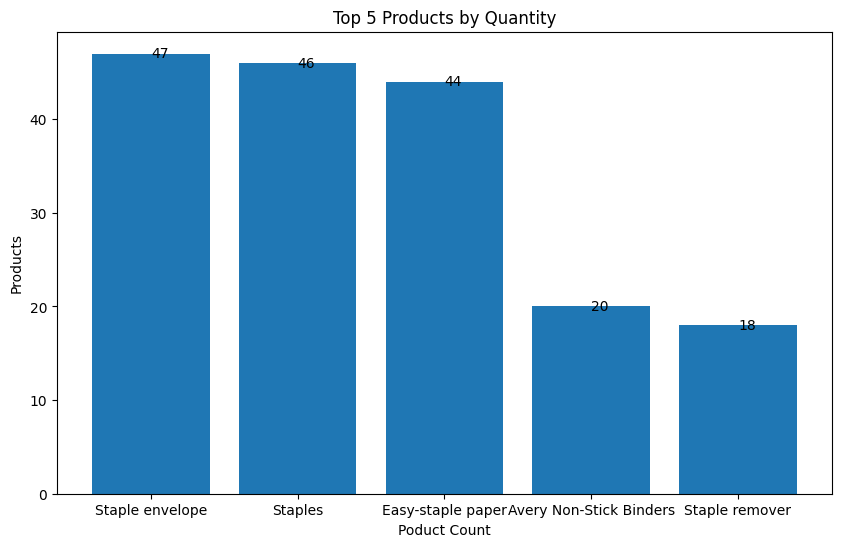

In [35]:
# TOP 5 SOLD PRODUCTS
products={}
for product in df["product_name"]:
    if product in products:
        products[product]=products[product]+1
    else:
        products[product]=1
products            

top5products=sorted(products.items(),key=lambda x:x[1],reverse=True)[:5]

product_names=[x[0] for x in top5products]
product_count=[x[1] for x in top5products]

plt.figure(figsize=(10,6))
plt.bar(product_names,product_count)
plt.xlabel("Poduct Count")
plt.ylabel("Products")
plt.title("Top 5 Products by Quantity")
for i,v in enumerate(product_count):
    plt.text(i,v,round(v,0),va="center")
plt.show()

In [36]:
# CUSTOMER SEGMENTATION
customer_sales=df.groupby("customer_name")["sales"].sum()
platinum=[]
Regular=[]
for customer,value in customer_sales.items():
    if value>5000:
        platinum.append(customer)
    else:
        Regular.append(customer)    
print(f"Customers in Platinum Category are : {len(platinum)}")
print(f"Customers in Regular category are : {len(Regular)}")

import plotly.express as px

# DATA FOR CHART
data=pd.DataFrame({"Category":["platinum","Regular"],"Count":[len(platinum),len(Regular)]})

fig = px.pie(data,names="Category",values="Count",hole=0.5)
fig.update_layout(title="Customer segmentation (Donut Chart)")
fig.show()


Customers in Platinum Category are : 113
Customers in Regular category are : 680


order_id
CA-2015-100006     378.0
CA-2015-100090     699.2
CA-2015-100293      91.1
CA-2015-100328       3.9
CA-2015-100363      21.4
                   ...  
US-2018-168802      18.4
US-2018-169320     171.4
US-2018-169488      56.9
US-2018-169502     113.4
US-2018-169551    1344.8
Name: sales, Length: 4916, dtype: float64


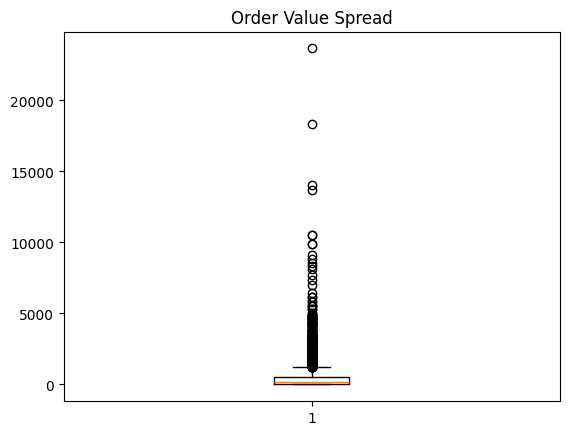

In [37]:
# AVERAGE ORDER VALUE
avg=df.groupby("order_id")["sales"].sum()
print(round(avg,1))

# BOX PLOT FOR order Value
plt.figure()
plt.boxplot(avg)
plt.title("Order Value Spread")
plt.show()